# 01 - Data quality

First pass on the market datasets and the portfolio inventory workbook.

## Goals

- load the three core datasets through the reusable loaders,
- inspect shapes and date ranges,
- review missing values,
- visualize maturity and strike distributions.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import ProjectConfig
from src.market import build_market_data_assets, load_option_quotes, load_rate_curves, market_dataset_summary
from src.portfolio import build_inventory_data_assets, inventory_dataset_summary, load_inventory_workbook


In [2]:
config = ProjectConfig.default(project_root)
WRITE_STAGE_FILES = False

if WRITE_STAGE_FILES:
    staged_assets = {}
    staged_assets.update(build_market_data_assets(config=config))
    staged_assets.update(build_inventory_data_assets(config=config))
    display(pd.Series({key: str(value) for key, value in staged_assets.items()}, name="staged_assets"))


In [3]:
rate_curves = load_rate_curves(config=config)
option_quotes = load_option_quotes(config=config)
inventory = load_inventory_workbook(config=config)

display(market_dataset_summary(rate_curves, option_quotes))
display(inventory_dataset_summary(inventory))


,dataset,rows,columns,min_date,max_date,entity_count
0,rate_curves,357978,6,1970-01-02,2026-02-25,3
1,options,10456,24,2026-03-02,2026-03-06,10


,sheet_name,rows,columns,min_date,max_date
0,autocalls,96,8,2026-02-27,2036-01-31
1,options,6,11,2026-02-27,2026-09-30
2,structured_notes,4,11,2026-02-27,2028-12-31
3,swaps,5,9,2026-02-27,2050-12-31


In [4]:
display(rate_curves.head())
display(option_quotes[["underlying", "option_type", "valuation_date", "expiration_date", "strike", "mid"]].head())
display(inventory["options"].head())


,country,curve_tenor,curve_tenor_years,observation_date,rate_percent,rate_decimal
0,France,10Y,10.0,1986-01-02,9.989,0.09989
1,France,10Y,10.0,1986-01-03,9.993,0.09993
2,France,10Y,10.0,1986-01-06,9.997,0.09997
3,France,10Y,10.0,1986-01-07,10.002,0.10002
4,France,10Y,10.0,1986-01-08,10.006,0.10006


,underlying,option_type,valuation_date,expiration_date,strike,mid
0,AAPL,call,2026-03-02,2026-03-20,90.0,175.200
1,AAPL,call,2026-03-02,2026-03-20,95.0,170.125
2,AAPL,call,2026-03-02,2026-03-20,100.0,165.025
3,AAPL,call,2026-03-02,2026-03-20,105.0,160.325
4,AAPL,call,2026-03-02,2026-03-20,110.0,155.325


,source_sheet,valuation_date,product_type,quantity,underlying,maturity_date,strike_1,strike_2,strike_3,barrier_type,barrier_level
0,options,2026-02-27,Call Spread,100000,AAPL,2026-03-30,240,280,NaN,<NA>,NaN
1,options,2026-02-27,Call Spread,100000,AAPL,2026-06-30,260,280,NaN,<NA>,NaN
2,options,2026-02-27,Butterfly,250000,AAPL,2026-06-30,200,230,250.0,<NA>,NaN
3,options,2026-02-27,Call,100000,AAPL,2026-06-30,260,280,NaN,OUT,290.0
4,options,2026-02-27,Put,100000,AAPL,2026-06-30,260,280,NaN,IN,240.0


In [5]:
missing_values = pd.concat(
    {
        "rate_curves": rate_curves.isna().mean().sort_values(ascending=False).head(6),
        "option_quotes": option_quotes.isna().mean().sort_values(ascending=False).head(6),
        "inventory_options": inventory["options"].isna().mean().sort_values(ascending=False).head(6),
    },
    axis=1,
)
missing_values


,rate_curves,option_quotes,inventory_options
country,0.0,NaN,NaN
curve_tenor,0.0,NaN,NaN
curve_tenor_years,0.0,NaN,NaN
observation_date,0.0,NaN,NaN
rate_percent,0.0,NaN,NaN
rate_decimal,0.0,NaN,NaN
implied_volatility,NaN,1.0,NaN
contract_symbol,NaN,0.0,NaN
underlying,NaN,0.0,NaN
ticker,NaN,0.0,NaN


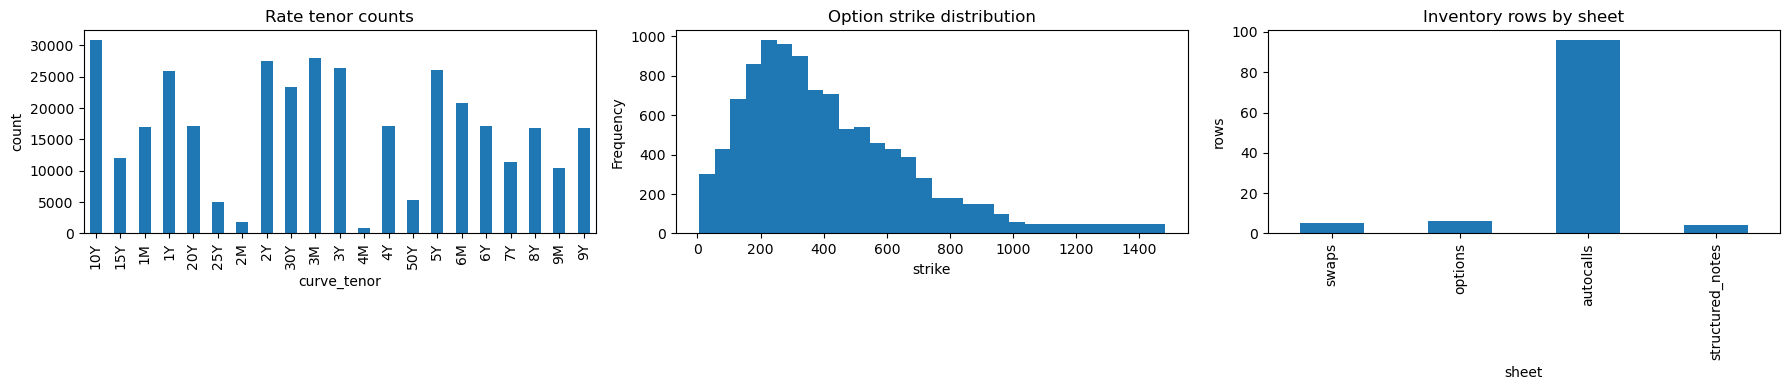

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

rate_curves["curve_tenor"].value_counts().sort_index().plot.bar(ax=axes[0], title="Rate tenor counts")
axes[0].set_xlabel("curve_tenor")
axes[0].set_ylabel("count")

option_quotes["strike"].plot.hist(ax=axes[1], bins=30, title="Option strike distribution")
axes[1].set_xlabel("strike")

pd.Series({sheet: len(frame) for sheet, frame in inventory.items()}).plot.bar(ax=axes[2], title="Inventory rows by sheet")
axes[2].set_xlabel("sheet")
axes[2].set_ylabel("rows")

plt.tight_layout()
